# Sales Forecasting Notebook



Cleaned version of the original Colab export. Each step is explained in a markdown cell before its code.

In [91]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### Step 1: Load the raw sales dataset from CSV

In [92]:
df = pd.read_csv("store_sales_data.csv")

### Step 2: Inspect the dataset structure and check for data quality issues

In [93]:
# (duplicate rows, missing values, column info)
df.info()

print("Duplicate rows:", df.duplicated().sum())
print("\nMissing values per column:")
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 25 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Customer ID        100000 non-null  object 
 1   Customer Name      100000 non-null  object 
 2   Last Name          100000 non-null  object 
 3   Date of Birth      100000 non-null  object 
 4   Sales              100000 non-null  float64
 5   Year               100000 non-null  int64  
 6   Outlet Type        100000 non-null  object 
 7   City Type          100000 non-null  object 
 8   Category of Goods  100000 non-null  object 
 9   Region             100000 non-null  object 
 10  Country            100000 non-null  object 
 11  Segment            100000 non-null  object 
 12  Sales Date         100000 non-null  object 
 13  Order ID           100000 non-null  object 
 14  Order Date         100000 non-null  object 
 15  Ship Date          100000 non-null  object 
 16  Shi

### Step 3: Convert date columns from string to proper datetime format

In [94]:
df['Sales Date'] = pd.to_datetime(df['Sales Date'], format='%d-%m-%Y')
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%d-%m-%Y')
df['Ship Date'] = pd.to_datetime(df['Ship Date'], format='%d-%m-%Y')

### Step 4: Explore the date range covered by the data

In [95]:
print("Earliest Order Date:", df['Order Date'].min())
print("Latest Order Date:", df['Order Date'].max())

Earliest Order Date: 2019-01-01 00:00:00
Latest Order Date: 2023-12-31 00:00:00


### Step 5: Review overall sales statistics and categorical field values

In [96]:
print(df['Sales'].describe())

print("Categories:")
print(df['Category of Goods'].unique())

print("\nRegions:")
print(df['Region'].unique())

print("\nSegments:")
print(df['Segment'].unique())

count    100000.000000
mean      25084.410142
std       14403.187686
min         100.570000
25%       12618.030000
50%       25134.695000
75%       37575.850000
max       49999.890000
Name: Sales, dtype: float64
Categories:
['Fast Food' 'Electric Appliances' 'Dairy Products'
 'Sessional Fruits & Vegetables' 'Furniture' 'Household Items']

Regions:
['East' 'South' 'West' 'North']

Segments:
['Consumer' 'Corporate']


### Step 6: Engineer calendar-based features from the Sales Date column

In [97]:
df["Sales_Year"] = df["Sales Date"].dt.year
df["Sales_Month"] = df["Sales Date"].dt.month
df["Sales_Quarter"] = df["Sales Date"].dt.quarter
df["Sales_Day"] = df["Sales Date"].dt.day
df["Sales_DayOfWeek"] = df["Sales Date"].dt.dayofweek
df["Sales_Week"] = df["Sales Date"].dt.isocalendar().week

### Step 7: Sort data chronologically and plot the daily sales trend

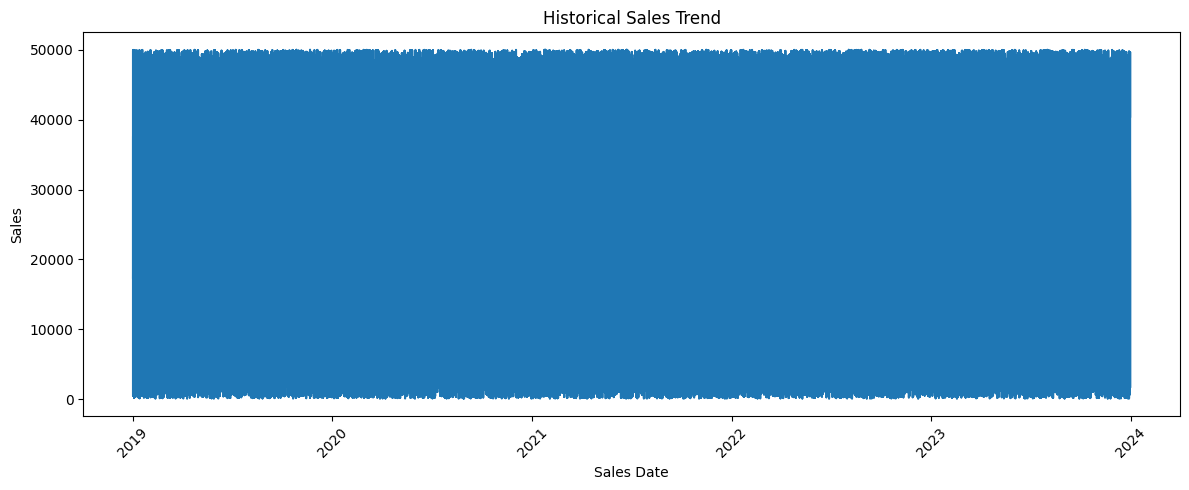

In [98]:
df = df.sort_values("Sales Date")

plt.figure(figsize=(12, 5))
plt.plot(df["Sales Date"], df["Sales"])
plt.xlabel("Sales Date")
plt.ylabel("Sales")
plt.title("Historical Sales Trend")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Step 8: Aggregate daily sales into monthly totals

In [99]:
monthly_sales = df.resample("ME", on="Sales Date")["Sales"].sum().reset_index()

### Step 9: Plot the monthly sales trend

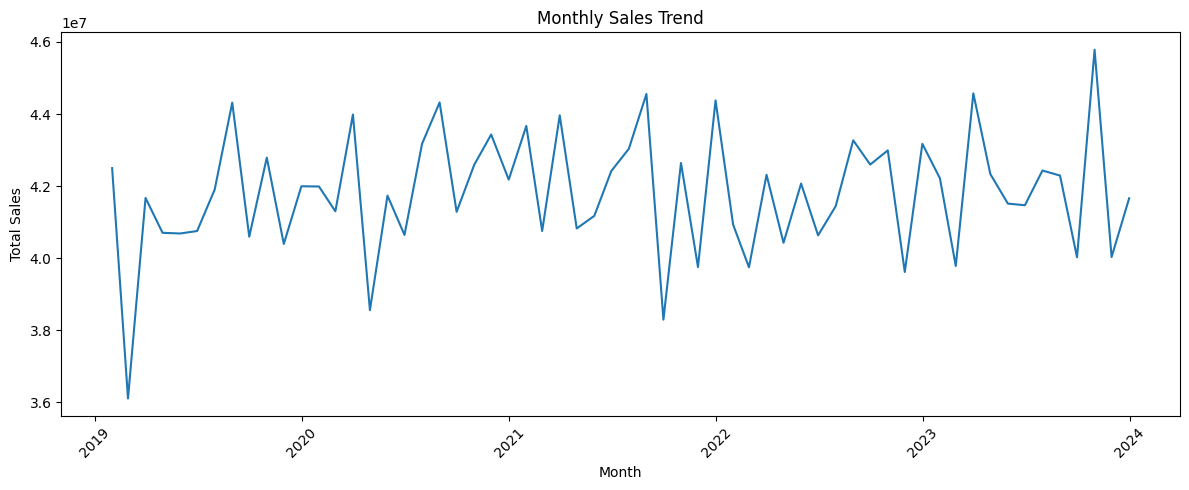

In [100]:
plt.figure(figsize=(12, 5))
plt.plot(
    monthly_sales["Sales Date"],
    monthly_sales["Sales"]
)
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.title("Monthly Sales Trend")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Step 10: Create numerical time features (Year, Month, Quarter) for modeling

In [101]:
monthly_sales["Year"] = monthly_sales["Sales Date"].dt.year
monthly_sales["Month"] = monthly_sales["Sales Date"].dt.month
monthly_sales["Quarter"] = monthly_sales["Sales Date"].dt.quarter

### Step 11: Define baseline model features (X) and target (y)

In [102]:
X = monthly_sales[["Year", "Month", "Quarter"]]
y = monthly_sales["Sales"]

print("Features:")
print(X.head())

print("\nTarget:")
print(y.head())

Features:
   Year  Month  Quarter
0  2019      1        1
1  2019      2        1
2  2019      3        1
3  2019      4        2
4  2019      5        2

Target:
0    42499773.01
1    36108584.87
2    41671799.08
3    40705110.78
4    40685569.30
Name: Sales, dtype: float64


### Step 12: Time-based train/test split (80% train, 20% test, chronological)

In [103]:
split = int(len(monthly_sales) * 0.8)

X_train = X.iloc[:split]
X_test = X.iloc[split:]

y_train = y.iloc[:split]
y_test = y.iloc[split:]

print("Training data:", len(X_train))
print("Testing data:", len(X_test))

Training data: 48
Testing data: 12


### Step 13: Train a baseline Linear Regression model

In [104]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

print("Model training completed.")

Model training completed.


### Step 14: Generate predictions on the test set

In [105]:
y_pred = model.predict(X_test)

print("Predicted Sales:")
print(y_pred[:10])

Predicted Sales:
[41550704.23981246 41572937.83199999 41595171.42418748 41876947.3368125
 41899180.92899999 41921414.52118748 42203190.4338125  42225424.02599999
 42247657.61818749 42529433.53081247]


### Step 15: Evaluate the baseline model (MAE, RMSE, R²)

In [106]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
print("Mean Absolute Error (MAE):", mae)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("Root Mean Squared Error (RMSE):", rmse)

r2 = r2_score(y_test, y_pred)
print("R² Score:", r2)

Mean Absolute Error (MAE): 1327581.3939270843
Root Mean Squared Error (RMSE): 1728160.3467119813
R² Score: -0.03340417525726491


### Step 16: Build a comparison table of actual vs predicted sales

In [107]:
comparison = pd.DataFrame({
    "Date": monthly_sales["Sales Date"].iloc[split:].values,
    "Actual Sales": y_test.values,
    "Predicted Sales": y_pred
})
print(comparison.head(10))

        Date  Actual Sales  Predicted Sales
0 2023-01-31   42217616.08     4.155070e+07
1 2023-02-28   39784238.89     4.157294e+07
2 2023-03-31   44573725.25     4.159517e+07
3 2023-04-30   42334580.67     4.187695e+07
4 2023-05-31   41514839.37     4.189918e+07
5 2023-06-30   41469599.94     4.192141e+07
6 2023-07-31   42432960.20     4.220319e+07
7 2023-08-31   42292498.60     4.222542e+07
8 2023-09-30   40025867.05     4.224766e+07
9 2023-10-31   45783283.54     4.252943e+07


### Step 17: Plot actual vs predicted sales for the test period

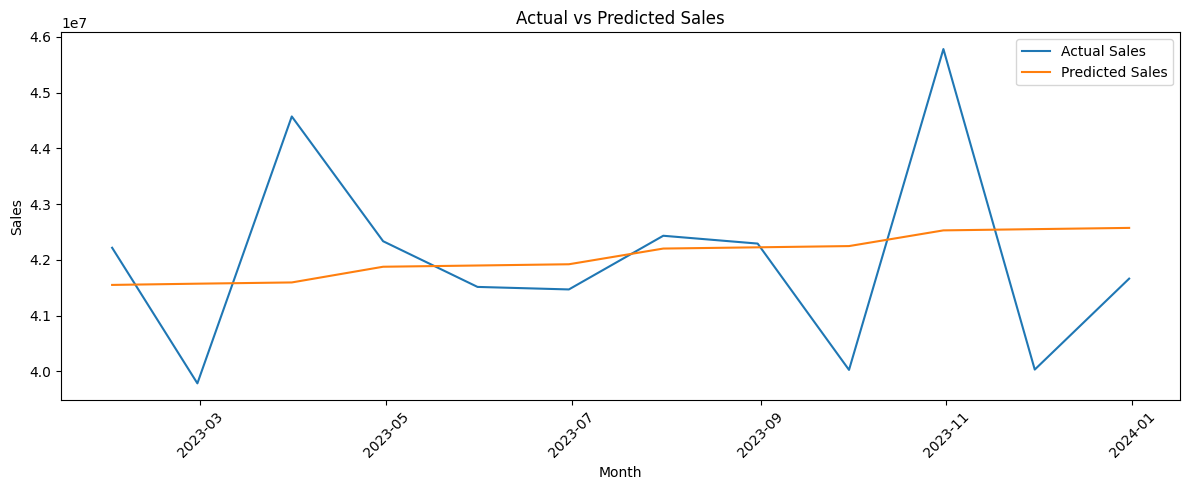

In [108]:
plt.figure(figsize=(12, 5))
plt.plot(
    comparison["Date"],
    comparison["Actual Sales"],
    label="Actual Sales"
)
plt.plot(
    comparison["Date"],
    comparison["Predicted Sales"],
    label="Predicted Sales"
)
plt.xlabel("Month")
plt.ylabel("Sales")
plt.title("Actual vs Predicted Sales")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Step 18: Build the next 12 future months to forecast

In [109]:
last_date = monthly_sales["Sales Date"].max()

future_dates = pd.date_range(
    start=last_date + pd.DateOffset(months=1),
    periods=12,
    freq="ME"
)

### Step 19: Create matching time features for the future dates

In [110]:
future_data = pd.DataFrame({
    "Sales Date": future_dates
})

future_data["Year"] = future_data["Sales Date"].dt.year
future_data["Month"] = future_data["Sales Date"].dt.month
future_data["Quarter"] = future_data["Sales Date"].dt.quarter

### Step 20: Forecast sales for the next 12 months using the baseline model

In [111]:
future_X = future_data[["Year", "Month", "Quarter"]]
future_data["Predicted Sales"] = model.predict(future_X)

print(future_data)

   Sales Date  Year  Month  Quarter  Predicted Sales
0  2024-01-31  2024      1        1     4.167299e+07
1  2024-02-29  2024      2        1     4.169522e+07
2  2024-03-31  2024      3        1     4.171745e+07
3  2024-04-30  2024      4        2     4.199923e+07
4  2024-05-31  2024      5        2     4.202146e+07
5  2024-06-30  2024      6        2     4.204370e+07
6  2024-07-31  2024      7        3     4.232547e+07
7  2024-08-31  2024      8        3     4.234771e+07
8  2024-09-30  2024      9        3     4.236994e+07
9  2024-10-31  2024     10        4     4.265171e+07
10 2024-11-30  2024     11        4     4.267395e+07
11 2024-12-31  2024     12        4     4.269618e+07


### Step 21: Plot historical sales alongside the future forecast

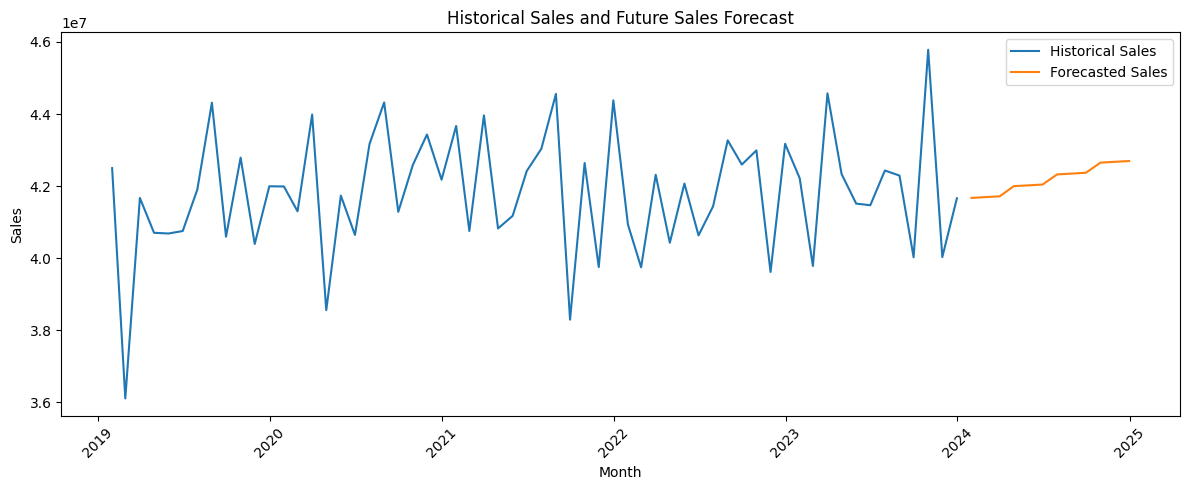

----- Model Performance -----
MAE  : 1327581.3939270843
RMSE : 1728160.3467119813
R²   : -0.03340417525726491


In [112]:
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_sales["Sales Date"],
    monthly_sales["Sales"],
    label="Historical Sales"
)
plt.plot(
    future_data["Sales Date"],
    future_data["Predicted Sales"],
    label="Forecasted Sales"
)
plt.xlabel("Month")
plt.ylabel("Sales")
plt.title("Historical Sales and Future Sales Forecast")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("----- Model Performance -----")
print("MAE  :", mae)
print("RMSE :", rmse)
print("R²   :", r2)

### Step 22: Engineer lag features (previous 1, 3, and 12 month sales)

In [113]:
monthly_sales["Lag_1"] = monthly_sales["Sales"].shift(1)
monthly_sales["Lag_3"] = monthly_sales["Sales"].shift(3)
monthly_sales["Lag_12"] = monthly_sales["Sales"].shift(12)

### Step 23: Engineer a rolling 3-month average sales feature

In [114]:
monthly_sales["Rolling_3_Month"] = (
    monthly_sales["Sales"]
    .shift(1)
    .rolling(3)
    .mean()
)

In [115]:
future_data.to_csv("sales_forecast.csv", index=False)

### Step 24: Check how many missing values the new lag/rolling features created

In [116]:
print(monthly_sales[
    ["Lag_1", "Lag_3", "Lag_12", "Rolling_3_Month"]
].isnull().sum())

Lag_1               1
Lag_3               3
Lag_12             12
Rolling_3_Month     3
dtype: int64


### Step 25: Drop rows where lag features are not available (start of series)

In [117]:
model_data = monthly_sales.dropna().copy()

print("Original rows:", len(monthly_sales))
print("Rows available for modeling:", len(model_data))

Original rows: 60
Rows available for modeling: 48


### Step 26: Define the feature set for the improved model

In [118]:
features = [
    "Year",
    "Month",
    "Lag_1",
    "Lag_3",
    "Lag_12",
    "Rolling_3_Month"
]

X = model_data[features]
y = model_data["Sales"]

print("Features used:")
print(features)

Features used:
['Year', 'Month', 'Lag_1', 'Lag_3', 'Lag_12', 'Rolling_3_Month']


### Step 27: Time-based train/test split for the improved model

In [119]:
split = int(len(model_data) * 0.8)

X_train = X.iloc[:split]
X_test = X.iloc[split:]

y_train = y.iloc[:split]
y_test = y.iloc[split:]

print("Training observations:", len(X_train))
print("Testing observations:", len(X_test))

Training observations: 38
Testing observations: 10


### Step 28: Train the improved Linear Regression model (with lag features)

In [120]:
improved_model = LinearRegression()
improved_model.fit(X_train, y_train)

y_pred_improved = improved_model.predict(X_test)

print("Improved model training completed.")

Improved model training completed.


### Step 29: Evaluate the improved model

In [121]:
mae_improved = mean_absolute_error(y_test, y_pred_improved)
rmse_improved = np.sqrt(mean_squared_error(y_test, y_pred_improved))
r2_improved = r2_score(y_test, y_pred_improved)

print("----- Improved Model Performance -----")
print("MAE  :", mae_improved)
print("RMSE :", rmse_improved)
print("R²   :", r2_improved)

print("========== MODEL ANALYSIS ==========")
print(f"MAE  : {mae_improved:,.2f}")
print(f"RMSE : {rmse_improved:,.2f}")
print(f"R²   : {r2_improved:.4f}")

print("\n========== DATA SUMMARY ==========")
print("Training observations:", len(X_train))
print("Testing observations :", len(X_test))
print("Features used        :", features)

----- Improved Model Performance -----
MAE  : 1483717.248890277
RMSE : 1847304.3660940437
R²   : -0.16572630574320302
========== MODEL ANALYSIS ==========
MAE  : 1,483,717.25
RMSE : 1,847,304.37
R²   : -0.1657

========== DATA SUMMARY ==========
Training observations: 38
Testing observations : 10
Features used        : ['Year', 'Month', 'Lag_1', 'Lag_3', 'Lag_12', 'Rolling_3_Month']


### Step 30: Train a Random Forest model for comparison

In [122]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    max_depth=5
)
rf_model.fit(X_train, y_train)

print("Random Forest model training completed.")

Random Forest model training completed.


### Step 31: Generate Random Forest predictions on the test set

In [123]:
y_pred_rf = rf_model.predict(X_test)

print("Random Forest predictions:")
print(y_pred_rf[:10])

Random Forest predictions:
[42095072.76014568 40221285.86942289 41746833.11334943 41599071.86055285
 42075903.83175755 42484477.69679784 42578986.06492259 42315279.77739184
 40539414.51929834 42482992.88016142]


### Step 32: Evaluate the Random Forest model

In [124]:
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("========== RANDOM FOREST PERFORMANCE ==========")
print(f"MAE  : {mae_rf:,.2f}")
print(f"RMSE : {rmse_rf:,.2f}")
print(f"R²   : {r2_rf:.4f}")

========== RANDOM FOREST PERFORMANCE ==========
MAE  : 1,285,094.85
RMSE : 1,741,253.30
R²   : -0.0357


### Step 33: Compare Linear Regression vs Random Forest performance

In [125]:
model_comparison = pd.DataFrame({
    "Model": [
        "Improved Linear Regression",
        "Random Forest"
    ],
    "MAE": [
        mae_improved,
        mae_rf
    ],
    "RMSE": [
        rmse_improved,
        rmse_rf
    ],
    "R²": [
        r2_improved,
        r2_rf
    ]
})
print(model_comparison)

                        Model           MAE          RMSE        R²
0  Improved Linear Regression  1.483717e+06  1.847304e+06 -0.165726
1               Random Forest  1.285095e+06  1.741253e+06 -0.035723


### Step 34: Plot actual vs Random Forest predicted sales

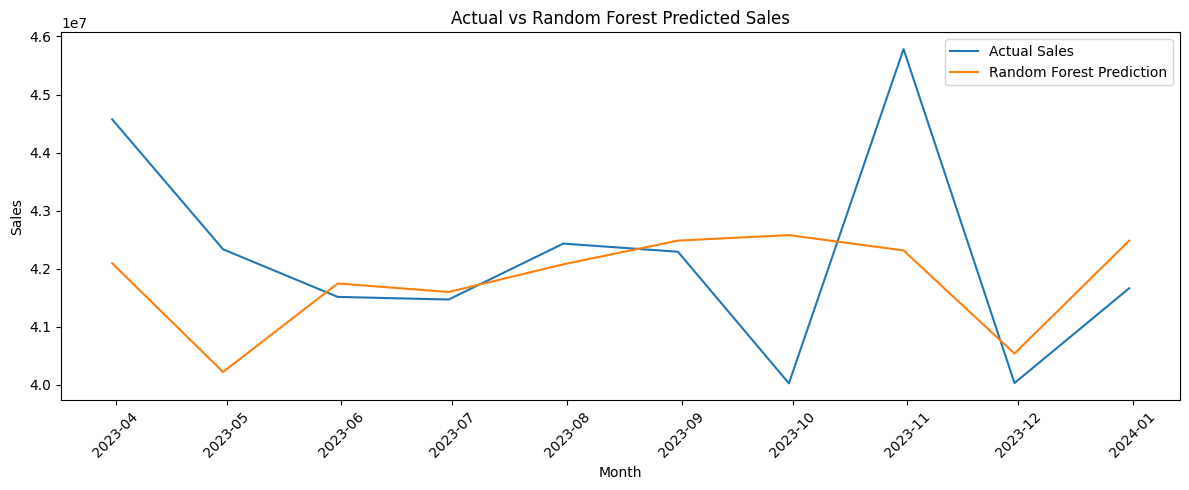

In [126]:
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_sales["Sales Date"].iloc[-len(y_test):],
    y_test.values,
    label="Actual Sales"
)
plt.plot(
    monthly_sales["Sales Date"].iloc[-len(y_test):],
    y_pred_rf,
    label="Random Forest Prediction"
)
plt.xlabel("Month")
plt.ylabel("Sales")
plt.title("Actual vs Random Forest Predicted Sales")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Step 35: Build a detailed Random Forest actual vs predicted table

In [127]:
comparison_rf = pd.DataFrame({
    "Date": monthly_sales["Sales Date"].iloc[-len(y_test):].values,
    "Actual": y_test.values,
    "Predicted_RF": y_pred_rf
})
print(comparison_rf)

        Date       Actual  Predicted_RF
0 2023-03-31  44573725.25  4.209507e+07
1 2023-04-30  42334580.67  4.022129e+07
2 2023-05-31  41514839.37  4.174683e+07
3 2023-06-30  41469599.94  4.159907e+07
4 2023-07-31  42432960.20  4.207590e+07
5 2023-08-31  42292498.60  4.248448e+07
6 2023-09-30  40025867.05  4.257899e+07
7 2023-10-31  45783283.54  4.231528e+07
8 2023-11-30  40031508.21  4.053941e+07
9 2023-12-31  41663521.90  4.248299e+07


### Step 36: Calculate MAPE (Mean Absolute Percentage Error) for Random Forest

In [128]:
mape_rf = np.mean(np.abs((y_test.values - y_pred_rf) / y_test.values)) * 100
print(f"MAPE: {mape_rf:.2f}%")

MAPE: 2.99%


### Step 37: Inspect Random Forest feature importance

In [129]:
importance = pd.DataFrame({
    "Feature": features,
    "Importance": rf_model.feature_importances_
}).sort_values("Importance", ascending=False)
print(importance)

           Feature  Importance
4           Lag_12    0.359897
2            Lag_1    0.172820
3            Lag_3    0.171218
5  Rolling_3_Month    0.143251
1            Month    0.107349
0             Year    0.045464


In [130]:
# Get the dates corresponding to the test data
dates_test = model_data.loc[y_test.index, "Sales Date"]

# Create Actual vs Predicted table
actual_vs_predicted = pd.DataFrame({
    "Sales Date": dates_test.values,
    "Actual Sales": y_test.values,
    "Predicted Sales": y_pred_rf
})

# Save for Power BI
actual_vs_predicted.to_csv("actual_vs_predicted.csv", index=False)

# Display the result
actual_vs_predicted

,Sales Date,Actual Sales,Predicted Sales
0,2023-03-31,44573725.25,4.209507e+07
1,2023-04-30,42334580.67,4.022129e+07
2,2023-05-31,41514839.37,4.174683e+07
3,2023-06-30,41469599.94,4.159907e+07
4,2023-07-31,42432960.20,4.207590e+07
5,2023-08-31,42292498.60,4.248448e+07
6,2023-09-30,40025867.05,4.257899e+07
7,2023-10-31,45783283.54,4.231528e+07
8,2023-11-30,40031508.21,4.053941e+07
9,2023-12-31,41663521.90,4.248299e+07


In [131]:
model_data.loc[y_test.index, "Sales Date"]

,Sales Date
50,2023-03-31
51,2023-04-30
52,2023-05-31
53,2023-06-30
54,2023-07-31
55,2023-08-31
56,2023-09-30
57,2023-10-31
58,2023-11-30
59,2023-12-31


In [132]:
y_pred_rf

array([42095072.76014568, 40221285.86942289, 41746833.11334943,
       41599071.86055285, 42075903.83175755, 42484477.69679784,
       42578986.06492259, 42315279.77739184, 40539414.51929834,
       42482992.88016142])

In [133]:
actual_vs_predicted = pd.DataFrame({
    "Sales Date": model_data.loc[y_test.index, "Sales Date"].values,
    "Actual Sales": y_test.values,
    "Predicted Sales": y_pred_rf
})

actual_vs_predicted

,Sales Date,Actual Sales,Predicted Sales
0,2023-03-31,44573725.25,4.209507e+07
1,2023-04-30,42334580.67,4.022129e+07
2,2023-05-31,41514839.37,4.174683e+07
3,2023-06-30,41469599.94,4.159907e+07
4,2023-07-31,42432960.20,4.207590e+07
5,2023-08-31,42292498.60,4.248448e+07
6,2023-09-30,40025867.05,4.257899e+07
7,2023-10-31,45783283.54,4.231528e+07
8,2023-11-30,40031508.21,4.053941e+07
9,2023-12-31,41663521.90,4.248299e+07


In [134]:
actual_vs_predicted.to_csv("actual_vs_predicted.csv", index=False)

In [135]:
from google.colab import files
files.download("actual_vs_predicted.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>